# Thesis Figure 4 â€” MCTS vs MCGS: Tree vs DAG

Illustrates the structural difference between **MCTS** and **MCGS**:
- **MCTS** â€” tree: the same region (frozenset of segments) can appear as multiple distinct nodes when reachable via different action sequences.
- **MCGS** â€” DAG: a transposition table merges nodes that represent the same region, regardless of path.

Each node thumbnail shows the image crop with the current region at full colour and all other segments dimmed.

Edit only the **Configuration** cell.

In [26]:
# â”€â”€ Configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
IMAGE_PATH = r"REPO_ROOT/images\images\imagenets_0050.jpg"

OVERRIDES = [
    "segmentation=slic",
    "segmentation.n_segments=300",
    "segmentation.compactness=20",
    "replacement=imagenet_mean",
]

# Set to an integer to skip model scoring and use a fixed seed segment.
# Set to None to derive the seed from real model scores (loads the model).
MANUAL_SEED_IDX = None

# Visual constants
CROP_PADDING = 5  # pixels of padding around the bounding box of all demo segments

NODE_SIZE = 0.15  # node axes width/height in normalised figure coordinates
REGION_CONTOUR_LW = 2.5  # linewidth of the coloured contour drawn around the region

EDGE_COLOR = "#444444"  # default edge colour
ROOT_COLOR = "#1565c0"  # blue  â€” root node
DUP_COLOR = "#d84315"  # orange-red â€” duplicate node (MCTS)
SHARE_COLOR = "#2e7d32"  # green â€” shared node (MCGS)
NODE_COLOR = "#212121"  # dark  â€” regular node

# Region highlight: semi-transparent colour overlay on selected segments
HIGHLIGHT_REGION = True
HIGHLIGHT_COLOR = [1.0, 0.85, 0.0]  # RGB in [0, 1] â€” golden yellow
HIGHLIGHT_ALPHA = 0.35  # opacity of the colour overlay

NODE_LABEL_FONTSIZE = 15  # set notation below each node, e.g. {s,A,B}
ACTION_LABEL_FONTSIZE = 15  # edge action labels, e.g. +A, +B
LEGEND_FONTSIZE = 8.5  # legend entries

OUTPUT_DIR = "output"

In [20]:
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.data.preprocessing import load_and_preprocess_image
from ciao.visualization.visualization import _to_hwc


OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}  |  repo: {REPO_ROOT}")

device: cpu  |  repo: REPO_ROOT/n

In [21]:
# â”€â”€ Load image & segmentation via Hydra â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(config_name="base", overrides=OVERRIDES)

img_tensor = load_and_preprocess_image(IMAGE_PATH, device=device)
input_batch = img_tensor.unsqueeze(0)

segmentation_fn = instantiate(cfg.segmentation)
image_graph = segmentation_fn(img_tensor)

img_np = _to_hwc(input_batch)  # [H, W, 3] float32 in [0, 1]
segs = image_graph.segments.cpu().numpy()  # [H, W] int32

print(f"Image shape : {img_np.shape}")
print(f"Segments    : {image_graph.num_segments} unique IDs")

Image shape : (224, 224, 3)
Segments    : 279 unique IDs


In [14]:
# â”€â”€ Select seed segment + 3 frontier neighbours â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if MANUAL_SEED_IDX is not None:
    seed_idx = MANUAL_SEED_IDX
else:
    from ciao.algorithm.builder import _select_seed_and_sign
    from ciao.model.predictor import ModelPredictor
    from ciao.scoring.region import log_odds_for_class
    from ciao.scoring.segments import calculate_segment_scores, create_surrogate_dataset

    replacement_fn = instantiate(cfg.replacement)
    replacement_image = replacement_fn(img_tensor)

    model = instantiate(cfg.model).to(device).eval()
    class_names = instantiate(cfg.classes)
    predictor = ModelPredictor(model=model, class_names=class_names)

    with torch.no_grad():
        logits = predictor.get_logits(input_batch)
    target_class_idx = int(logits.argmax(dim=1)[0].item())
    original_log_odds = log_odds_for_class(logits, target_class_idx)

    print("Computing surrogate scoresâ€¦")
    X, y = create_surrogate_dataset(
        predictor=predictor,
        input_batch=input_batch,
        replacement_image=replacement_image,
        image_graph=image_graph,
        target_class_idx=target_class_idx,
        original_log_odds=original_log_odds,
        neighborhood_distance=1,
        batch_size=16,
    )
    scores = calculate_segment_scores(X, y)
    seed_idx, _ = _select_seed_and_sign(
        scores=scores,
        available_segments=list(scores.keys()),
        sigma=1,
    )

# Pick 3 adjacent frontier segments as demo actions A, B, C
all_frontier = sorted(image_graph.adj_list[seed_idx])
assert len(all_frontier) >= 3, (
    f"Seed {seed_idx} has fewer than 3 neighbours: {all_frontier}"
)
seg_A, seg_B, seg_C = all_frontier[0], all_frontier[1], all_frontier[2]

LABELS = {seed_idx: "s", seg_A: "A", seg_B: "B", seg_C: "C"}
print(f"Seed: {seed_idx}  A: {seg_A}  B: {seg_B}  C: {seg_C}")

Computing surrogate scoresâ€¦
Seed: 96  A: 71  B: 86  C: 92


In [27]:
# â”€â”€ Fixed crop box covering all demo segments â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ys_all, xs_all = np.where(np.isin(segs, [seed_idx, seg_A, seg_B, seg_C]))

x1_c = max(0, int(xs_all.min()) - CROP_PADDING)
y1_c = max(0, int(ys_all.min()) - CROP_PADDING)
x2_c = min(img_np.shape[1], int(xs_all.max()) + CROP_PADDING + 1)
y2_c = min(img_np.shape[0], int(ys_all.max()) + CROP_PADDING + 1)
CROP_BOX = (x1_c, y1_c, x2_c, y2_c)

print(f"Crop box: {CROP_BOX}  ({x2_c - x1_c}Ã—{y2_c - y1_c} px)")

Crop box: (137, 44, 188, 84)  (51Ã—40 px)


In [28]:
# â”€â”€ Drawing helpers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
HALF = NODE_SIZE / 2

# Arrows connect at this offset from node centre toward the opposing node,
# so they arrive at the inner edge rather than dead-centre top/bottom.
_H_INSET = HALF * 0.55


def node_label(seg_ids):
    """Format a region as set notation, e.g. '{s,A,B}'."""
    return "{" + ",".join(LABELS[k] for k in seg_ids) + "}"


def make_node_image(region):
    """White background with region at full colour (+ optional highlight)."""
    canvas = np.ones_like(img_np)
    mask = np.isin(segs, sorted(region))
    canvas[mask] = img_np[mask]
    if HIGHLIGHT_REGION:
        h = np.array(HIGHLIGHT_COLOR, dtype=np.float32)
        canvas[mask] = canvas[mask] * (1 - HIGHLIGHT_ALPHA) + h * HIGHLIGHT_ALPHA
    x1, y1, x2, y2 = CROP_BOX
    return canvas[y1:y2, x1:x2]


def add_node(fig, cx, cy, region, border_color=None, label=""):
    """Add a frameless region thumbnail at normalised figure position (cx, cy)."""
    if border_color is None:
        border_color = NODE_COLOR
    ax = fig.add_axes([cx - HALF, cy - HALF, NODE_SIZE, NODE_SIZE])
    ax.imshow(make_node_image(region), interpolation="bilinear", aspect="auto")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    x1, y1, x2, y2 = CROP_BOX
    crop_mask = np.isin(segs[y1:y2, x1:x2], sorted(region)).astype(float)
    ax.contour(
        crop_mask, levels=[0.5], colors=[border_color], linewidths=[REGION_CONTOUR_LW]
    )
    if label:
        fig.text(
            cx,
            cy - HALF - 0.016,
            label,
            ha="center",
            va="top",
            fontsize=NODE_LABEL_FONTSIZE,
            color="#333333",
            fontfamily="monospace",
        )
    return ax


def draw_edge(
    ax_bg,
    px,
    py,
    cx,
    cy,
    action_label="",
    rad=0.0,
    color=None,
    label_offset=(0.012, 0.0),
):
    """Directed arrow from parent to child (figure coords).

    Connection points are shifted horizontally toward each other so arrows
    arrive at the inner edge of each node rather than dead-centre.

    label_offset: (dx, dy) added to the chord midpoint to place the label.
    For curved edges use this to keep the label clear of the arc.
    """
    if color is None:
        color = EDGE_COLOR
    sign = 1 if cx > px else (-1 if cx < px else 0)
    h = _H_INSET * sign
    x1, y1 = px + h, py - HALF  # parent exits toward child
    x2, y2 = cx - h, cy + HALF  # child entered from parent side
    ax_bg.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=1.8,
            connectionstyle=f"arc3,rad={rad}",
        ),
        annotation_clip=False,
    )
    if action_label:
        mid_x = (x1 + x2) / 2 + label_offset[0]
        mid_y = (y1 + y2) / 2 + label_offset[1]
        ax_bg.text(
            mid_x,
            mid_y,
            action_label,
            ha="center",
            va="center",
            fontsize=ACTION_LABEL_FONTSIZE,
            color="#444444",
            style="italic",
            bbox=dict(facecolor="white", edgecolor="none", pad=2),
        )

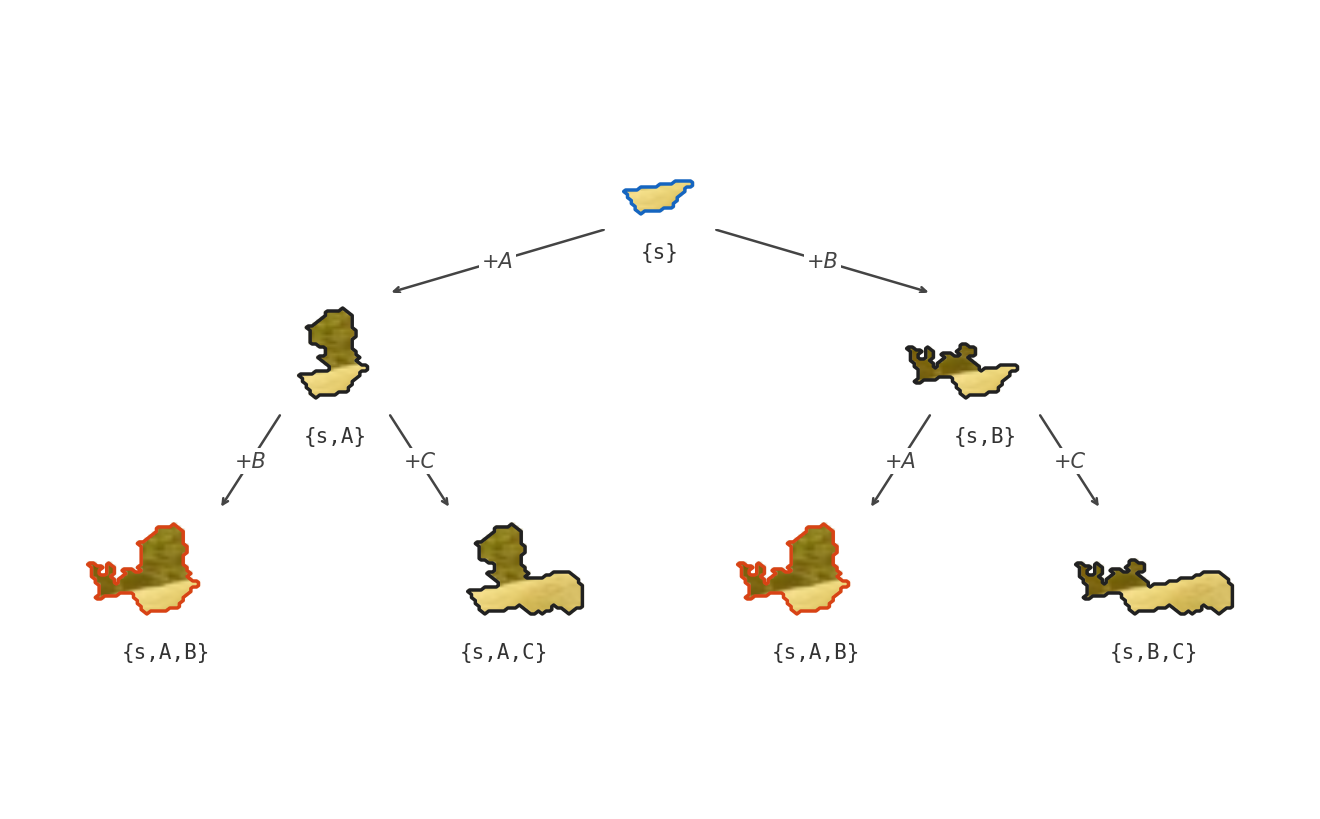

Saved â†’ output\mcts_tree.png


In [29]:
# â”€â”€ Figure: MCTS tree â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig_mcts = plt.figure(figsize=(13, 8), facecolor="white")

# Background axes for edge arrows (rendered before node axes so nodes sit on top)
ax_bg = fig_mcts.add_axes([0, 0, 1, 1], facecolor="none")
ax_bg.set_xlim(0, 1)
ax_bg.set_ylim(0, 1)
ax_bg.axis("off")

# â”€â”€ Regions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
r_s = frozenset({seed_idx})
r_A = frozenset({seed_idx, seg_A})
r_B = frozenset({seed_idx, seg_B})
r_AB = frozenset({seed_idx, seg_A, seg_B})
r_AC = frozenset({seed_idx, seg_A, seg_C})
r_BC = frozenset({seed_idx, seg_B, seg_C})

# â”€â”€ Node positions (cx, cy) in normalised figure coords â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
pos = {
    "root": (0.50, 0.80),
    "A": (0.25, 0.57),
    "B": (0.75, 0.57),
    "AB1": (0.12, 0.30),  # reached via s â†’ A â†’ +B
    "AC": (0.38, 0.30),  # reached via s â†’ A â†’ +C
    "BA": (0.62, 0.30),  # reached via s â†’ B â†’ +A  (same region as AB1!)
    "BC": (0.88, 0.30),  # reached via s â†’ B â†’ +C
}

# â”€â”€ Edges â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for parent, child, lbl in [
    ("root", "A", f"+{LABELS[seg_A]}"),
    ("root", "B", f"+{LABELS[seg_B]}"),
    ("A", "AB1", f"+{LABELS[seg_B]}"),
    ("A", "AC", f"+{LABELS[seg_C]}"),
    ("B", "BA", f"+{LABELS[seg_A]}"),
    ("B", "BC", f"+{LABELS[seg_C]}"),
]:
    draw_edge(ax_bg, *pos[parent], *pos[child], action_label=lbl, label_offset=(0, 0))

# â”€â”€ Nodes (added after edges so they render on top) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
add_node(fig_mcts, *pos["root"], r_s, ROOT_COLOR, label=node_label([seed_idx]))
add_node(fig_mcts, *pos["A"], r_A, NODE_COLOR, label=node_label([seed_idx, seg_A]))
add_node(fig_mcts, *pos["B"], r_B, NODE_COLOR, label=node_label([seed_idx, seg_B]))
add_node(
    fig_mcts, *pos["AB1"], r_AB, DUP_COLOR, label=node_label([seed_idx, seg_A, seg_B])
)
add_node(
    fig_mcts, *pos["AC"], r_AC, NODE_COLOR, label=node_label([seed_idx, seg_A, seg_C])
)
add_node(
    fig_mcts, *pos["BA"], r_AB, DUP_COLOR, label=node_label([seed_idx, seg_A, seg_B])
)
add_node(
    fig_mcts, *pos["BC"], r_BC, NODE_COLOR, label=node_label([seed_idx, seg_B, seg_C])
)

# â”€â”€ Legend â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
legend_handles = [
    mpatches.Patch(facecolor="white", edgecolor=ROOT_COLOR, lw=2, label="root"),
    mpatches.Patch(facecolor="white", edgecolor=NODE_COLOR, lw=2, label="node"),
    mpatches.Patch(
        facecolor="white",
        edgecolor=DUP_COLOR,
        lw=2,
        label="duplicate (same region, separate node)",
    ),
]
# ax_bg.legend(handles=legend_handles, loc="upper left", fontsize=LEGEND_FONTSIZE,
#             framealpha=0.95, edgecolor="#bbbbbb", borderpad=0.9)
#
# fig_mcts.suptitle("Monte Carlo Tree Search â€” same region appears as separate nodes",
#                  fontsize=13, fontweight="bold", y=0.97)

fig_mcts.savefig(OUT / "mcts_tree.png", dpi=150, bbox_inches="tight")
fig_mcts.savefig(OUT / "mcts_tree.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {OUT / 'mcts_tree.png'}")

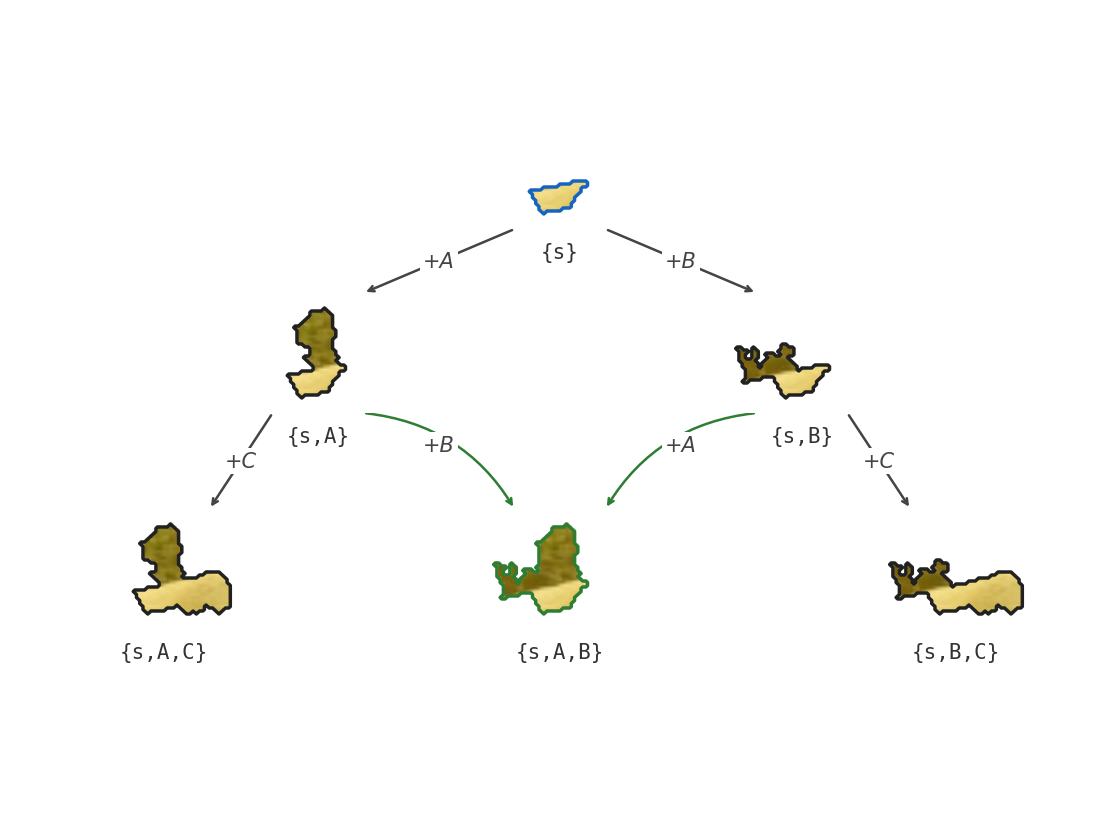

Saved â†’ output\mcgs_dag.png


In [30]:
# â”€â”€ Figure: MCGS DAG â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig_mcgs = plt.figure(figsize=(11, 8), facecolor="white")

ax_bg = fig_mcgs.add_axes([0, 0, 1, 1], facecolor="none")
ax_bg.set_xlim(0, 1)
ax_bg.set_ylim(0, 1)
ax_bg.axis("off")

# â”€â”€ Regions â€” {s,A,B} is ONE shared node â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
r_s = frozenset({seed_idx})
r_A = frozenset({seed_idx, seg_A})
r_B = frozenset({seed_idx, seg_B})
r_AB = frozenset({seed_idx, seg_A, seg_B})  # shared via transposition table
r_AC = frozenset({seed_idx, seg_A, seg_C})
r_BC = frozenset({seed_idx, seg_B, seg_C})

# â”€â”€ Node positions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
pos_g = {
    "root": (0.50, 0.80),
    "A": (0.28, 0.57),
    "B": (0.72, 0.57),
    "AC": (0.14, 0.30),
    "AB": (0.50, 0.30),  # shared â€” receives edges from both A and B
    "BC": (0.86, 0.30),
}

# â”€â”€ Straight edges â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for parent, child, lbl in [
    ("root", "A", f"+{LABELS[seg_A]}"),
    ("root", "B", f"+{LABELS[seg_B]}"),
    ("A", "AC", f"+{LABELS[seg_C]}"),
    ("B", "BC", f"+{LABELS[seg_C]}"),
]:
    draw_edge(
        ax_bg, *pos_g[parent], *pos_g[child], action_label=lbl, label_offset=(0, 0)
    )

# â”€â”€ Converging edges to the shared node (curved, coloured) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# label_offset pushes each label outward from the arc interior
draw_edge(
    ax_bg,
    *pos_g["A"],
    *pos_g["AB"],
    action_label=f"+{LABELS[seg_B]}",
    rad=-0.25,
    color=SHARE_COLOR,
    label_offset=(0, 0.02),
)
draw_edge(
    ax_bg,
    *pos_g["B"],
    *pos_g["AB"],
    action_label=f"+{LABELS[seg_A]}",
    rad=0.25,
    color=SHARE_COLOR,
    label_offset=(0, 0.02),
)

# â”€â”€ Nodes â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
add_node(fig_mcgs, *pos_g["root"], r_s, ROOT_COLOR, label=node_label([seed_idx]))
add_node(fig_mcgs, *pos_g["A"], r_A, NODE_COLOR, label=node_label([seed_idx, seg_A]))
add_node(fig_mcgs, *pos_g["B"], r_B, NODE_COLOR, label=node_label([seed_idx, seg_B]))
add_node(
    fig_mcgs, *pos_g["AC"], r_AC, NODE_COLOR, label=node_label([seed_idx, seg_A, seg_C])
)
add_node(
    fig_mcgs,
    *pos_g["AB"],
    r_AB,
    SHARE_COLOR,
    label=node_label([seed_idx, seg_A, seg_B]),
)
add_node(
    fig_mcgs, *pos_g["BC"], r_BC, NODE_COLOR, label=node_label([seed_idx, seg_B, seg_C])
)

# â”€â”€ Legend â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
legend_handles_g = [
    mpatches.Patch(facecolor="white", edgecolor=ROOT_COLOR, lw=2, label="root"),
    mpatches.Patch(facecolor="white", edgecolor=NODE_COLOR, lw=2, label="node"),
    mpatches.Patch(
        facecolor="white",
        edgecolor=SHARE_COLOR,
        lw=2,
        label="shared node (transposition table)",
    ),
]
# ax_bg.legend(handles=legend_handles_g, loc="upper left", fontsize=LEGEND_FONTSIZE,
#             framealpha=0.95, edgecolor="#bbbbbb", borderpad=0.9)
#
# fig_mcgs.suptitle("Monte Carlo Graph Search â€” same region shared as one node (DAG)",
#                  fontsize=13, fontweight="bold", y=0.97)

fig_mcgs.savefig(OUT / "mcgs_dag.png", dpi=150, bbox_inches="tight")
fig_mcgs.savefig(OUT / "mcgs_dag.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {OUT / 'mcgs_dag.png'}")